# Download helper funtion from github

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
#Solo ejecutar una vez
import wget
filename = wget.download('https://raw.githubusercontent.com/HSAkash/Banana-Leaf-Dataset/main/helper_functions.py')

ModuleNotFoundError: No module named 'wget'

In [ ]:
! pip install wget

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/


# Import Libraries

In [ ]:
import tensorflow as tf
#from tensorflow.python.client import device_lib

print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))
#device_lib.list_local_devices()

Num GPUs Available:  1


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from helper_functions import bestWeightModelEvaluate, plot_loss_curves

# Data

## Image path

In [ ]:
train_dir = "./drive/MyDrive/Banana/train"
test_dir = "./drive/MyDrive/Banana/test"
valid_dir = "./drive/MyDrive/Banana/val"

## Data Rescaling and augmentation

In [ ]:
data_augmentation = tf.keras.Sequential([
  tf.keras.layers.experimental.preprocessing.RandomFlip("horizontal",input_shape=(224, 224, 3)),
  tf.keras.layers.experimental.preprocessing.RandomRotation(0.2),
  tf.keras.layers.experimental.preprocessing.RandomZoom(0.2),
  tf.keras.layers.experimental.preprocessing.RandomHeight(0.2),
  tf.keras.layers.experimental.preprocessing.RandomWidth(0.2),
  tf.keras.layers.experimental.preprocessing.Rescaling(1./255)
], name ="data_augmentation")

## Load datasets (Shuffle and prefetch)

In [ ]:
import tensorflow as tf

IMG_SIZE = (224, 224)
BATCH_SIZE = 32
train_data = tf.keras.preprocessing.image_dataset_from_directory(
    directory = train_dir,
    image_size = IMG_SIZE,
    label_mode = 'categorical',
    batch_size = BATCH_SIZE,
    shuffle = True
).cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)

test_data = tf.keras.preprocessing.image_dataset_from_directory(
    directory = test_dir,
    image_size = IMG_SIZE,
    label_mode = 'categorical',
    batch_size = BATCH_SIZE
).cache().prefetch(buffer_size=tf.data.AUTOTUNE)

valid_datasets = tf.keras.preprocessing.image_dataset_from_directory(
    directory = valid_dir,
    image_size = IMG_SIZE,
    label_mode = 'categorical',
    batch_size = BATCH_SIZE
)

class_names = valid_datasets.class_names
valid_data = valid_datasets.cache().prefetch(buffer_size=tf.data.AUTOTUNE)

Found 777 files belonging to 4 classes.
Found 80 files belonging to 4 classes.
Found 80 files belonging to 4 classes.


## Visualize data

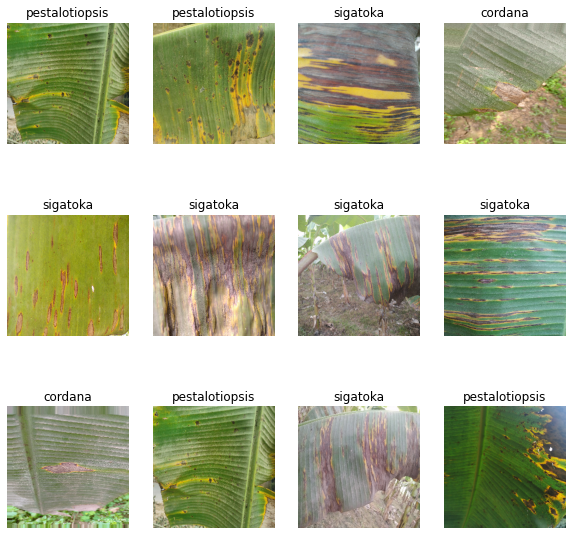

In [ ]:
plt.figure(figsize=(10,10))
for image_batch,label_batch in train_data.take(1):
    for i in range(0,12):
        plt.subplot(3,4,i+1)
        plt.imshow(image_batch[i].numpy().astype("uint32"))
        plt.title(class_names[np.argmax(label_batch[i])])
        plt.axis("off")

## Create Checkpoint

In [ ]:
checkpoint_path = "./checkPoint/cp.ckpt"
checkpoint_callback = tf.keras.callbacks.ModelCheckpoint(
    checkpoint_path,
    save_weights_only=True,
    monitor='val_accuracy',
    save_best_only=True
)

# Create model

In [ ]:
import tensorflow as tf

model = tf.keras.Sequential([
    data_augmentation,
    tf.keras.layers.Conv2D(20, 3, activation='relu'),
    tf.keras.layers.MaxPool2D(pool_size=2),
    tf.keras.layers.Conv2D(20, 3, activation='relu'),
    tf.keras.layers.MaxPool2D(pool_size=2),
    tf.keras.layers.Conv2D(20, 3, activation='relu'),
    tf.keras.layers.MaxPool2D(pool_size=2),
    tf.keras.layers.Conv2D(20, 3, activation='relu'),
    tf.keras.layers.MaxPool2D(pool_size=2),
    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Dense(len(class_names), activation='softmax', name='output_layers')

])

In [ ]:
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 data_augmentation (Sequenti  (None, None, None, 3)    0         
 al)                                                             
                                                                 
 conv2d (Conv2D)             (None, None, None, 20)    560       
                                                                 
 max_pooling2d (MaxPooling2D  (None, None, None, 20)   0         
 )                                                               
                                                                 
 conv2d_1 (Conv2D)           (None, None, None, 20)    3620      
                                                                 
 max_pooling2d_1 (MaxPooling  (None, None, None, 20)   0         
 2D)                                                             
                                                        

## Compile model

In [ ]:
model.compile(
    loss = 'categorical_crossentropy',
    optimizer = tf.keras.optimizers.Adam(),
    metrics = ['accuracy']
)

## Fit model with 1100 epochs

In [ ]:
history = model.fit(
    train_data,
    epochs=1100,
    validation_data = test_data,
    validation_steps = len(test_data),
    callbacks = [
        checkpoint_callback,
    ]
)

Epoch 1/1100
25/25 [==============================] - 65s 2s/step - loss: 1.2584 - accuracy: 0.5431 - val_loss: 1.6605 - val_accuracy: 0.2500
Epoch 2/1100
25/25 [==============================] - 8s 333ms/step - loss: 1.0724 - accuracy: 0.5573 - val_loss: 1.5172 - val_accuracy: 0.2500
Epoch 3/1100
25/25 [==============================] - 9s 342ms/step - loss: 0.9826 - accuracy: 0.5624 - val_loss: 1.4164 - val_accuracy: 0.3000
Epoch 4/1100
25/25 [==============================] - 8s 324ms/step - loss: 0.9300 - accuracy: 0.5869 - val_loss: 1.2901 - val_accuracy: 0.3375
Epoch 5/1100
25/25 [==============================] - 8s 321ms/step - loss: 0.9001 - accuracy: 0.6178 - val_loss: 1.1599 - val_accuracy: 0.5250
Epoch 6/1100
25/25 [==============================] - 8s 326ms/step - loss: 0.8689 - accuracy: 0.6448 - val_loss: 1.1404 - val_accuracy: 0.5000
Epoch 7/1100
25/25 [==============================] - 7s 283ms/step - loss: 0.8313 - accuracy: 0.6422 - val_loss: 1.1189 - val_accuracy: 0

## Plot model history

In [ ]:
plot_loss_curves(history)

## Evaluate

In [ ]:
model.evaluate(test_data), model.evaluate(valid_data)

### Check best weight validation data percentance

In [ ]:
bestWeightModelEvaluate(
    model = model,
    weightPath = checkpoint_path,
    data = test_data
)
bestWeightModelEvaluate(
    model = model,
    weightPath = checkpoint_path,
    data = valid_data
)

# Load model
pretrain model.
Same model has been train before

### Download pretrain model

In [ ]:
filename2 = wget.download('https://github.com/HSAkash/Banana-Leaf-Dataset/raw/main/pretrain_banana_model.h5')

In [ ]:
load_model = tf.keras.models.load_model("./pretrain_banana_model.h5")

### Summary of load data

In [ ]:
load_model.summary()

### Main model summary.
main model and load model are save

In [ ]:
model.summary()

## Evaluate load model with valid data and test_data

In [ ]:
test_eval, valid_eval = load_model.evaluate(test_data), load_model.evaluate(valid_data)
print(f"""
test data evaluation : {test_eval}
valid data evaluation : {valid_eval}
""")

## Predicting the values

In [ ]:
predictions = load_model.predict(test_data)
predictions = np.argmax(predictions, axis=-1)
predictions.shape

### Visualize prediction

In [ ]:
plt.figure(figsize=(12,12))
for image_batch,label_batch in test_data.take(1):
    for i in range(0,12):
        plt.subplot(3,4,i+1)
        plt.imshow(image_batch[i].numpy().astype("uint32"))
        true_class = class_names[np.argmax(label_batch[i])]
        predict_class = class_names[predictions[i]]
        title = f"""True: {true_class}\n Predict: {predict_class}"""
        plt.title(title, color='g' if true_class==predict_class else 'r')
        plt.axis("off")